In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

from scipy.stats import linregress
import DataProcessor

In [2]:
RUPTURE_POSITIONS = [105, 100, 95, 90, 85, 80, 75, 65, 55, 45, 35, 25, 15, 5]
MESH_SIZES = [100.0, 95.0, 90.0, 80.0, 70.0, 65.0, 60.0, 55.0, 50.0, 40.0, 39.0, 38.0, 37.0, 36.0, 35.0, 34.0, 33.0, 32.0, 31.0, 30.0, 29.0, 28.0, 27.0, 26.0, 25.0, 24.0, 23.0, 22.0, 21.0, 20.0, 19.0, 18.0, 17.0, 16.0, 15.0, 14.0, 13.0, 12.0, 11.0, 10.0, 9.0, 8.0, 4.0, 2.0, 1.5]

E_AVERAGE = []
E_STD = []

G_AVERAGE = []
G_STD = []

In [3]:
for MESH_SIZE in MESH_SIZES:
    folder_path = f"./MeshDC/{MESH_SIZE:.1f}mm"

    spring_energies = []

    for RUPTURE_POSITION in RUPTURE_POSITIONS:
        
        filename = f'strain-energy-{RUPTURE_POSITION}.npz'
        file_path = os.path.join(folder_path, filename)
        if not os.path.exists(file_path):
            print(f"[WARNING] File {filename} not found. Skipping.")
            continue
        data = np.load(file_path)
        spring_energies.append(data.get('ELSE-Spring', np.nan))


    spring_energies = np.array(spring_energies)
    G_spring = -np.gradient(spring_energies, RUPTURE_POSITIONS)

    E_AVERAGE.append(np.mean(spring_energies))
    E_STD.append(np.std(spring_energies))

    G_AVERAGE.append(np.mean(G_spring))
    G_STD.append(np.std(G_spring))

    plot_individual = True
    if plot_individual:

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

        ax1.plot(RUPTURE_POSITIONS, spring_energies, 's-', label='Spring Energy')
        ax1.set_ylabel('Strain Energy')
        ax1.set_title(f'Spring Energy vs. Rupture Position, Displacement Control, {MESH_SIZE:.1f}MPa')
        ax1.grid(True)
        ax1.legend()
        ax2.plot(RUPTURE_POSITIONS, G_spring, 's-', label='Spring Energy Gradient', color='tab:orange')
        ax2.set_xlabel('Rupture Position (mm)')
        ax2.set_ylabel('Energy Gradient')
        ax2.set_title('Gradient of Spring Energy vs. Rupture Position')
        ax2.grid(True)
        ax2.legend()

        plt.tight_layout()
        plt.savefig(f'./MeshDC/Plots/DC-{MESH_SIZE:.1f}mm.pdf', dpi=300)
        # plt.show()
        plt.close()


MESH_SIZES = np.array(MESH_SIZES)
G_AVERAGE = np.array(G_AVERAGE)
G_STD     = np.array(G_STD)

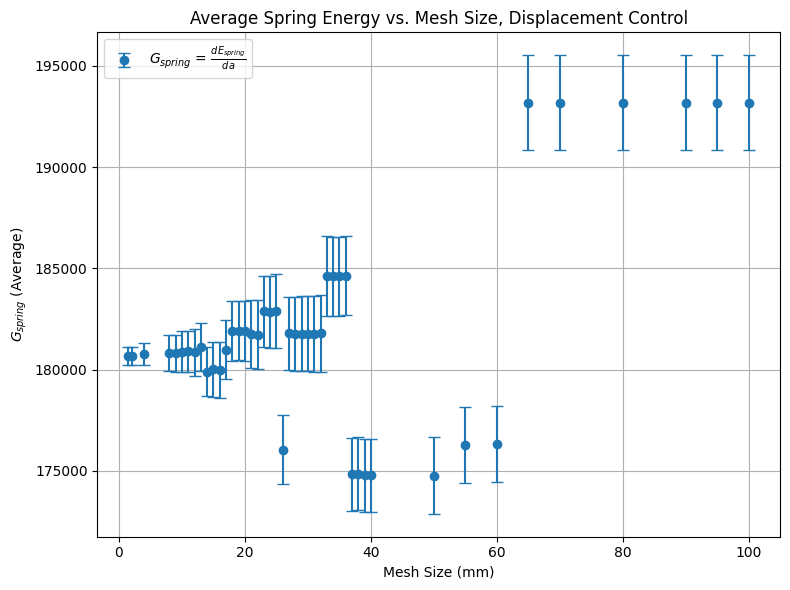

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(MESH_SIZES, E_AVERAGE, yerr=E_STD, fmt='o', capsize=4, label=r'$G_{spring}$ = $\frac{dE_{spring}}{da}$')
ax.set_xlabel('Mesh Size (mm)')
ax.set_ylabel(r'$G_{spring}$ (Average)')
ax.legend()
ax.grid(True)
plt.title('Average Spring Energy vs. Mesh Size, Displacement Control')
plt.tight_layout()
plt.savefig('./MeshDC/Plots/DC-Mesh-E.pdf', dpi=300)
plt.show()
plt.close()

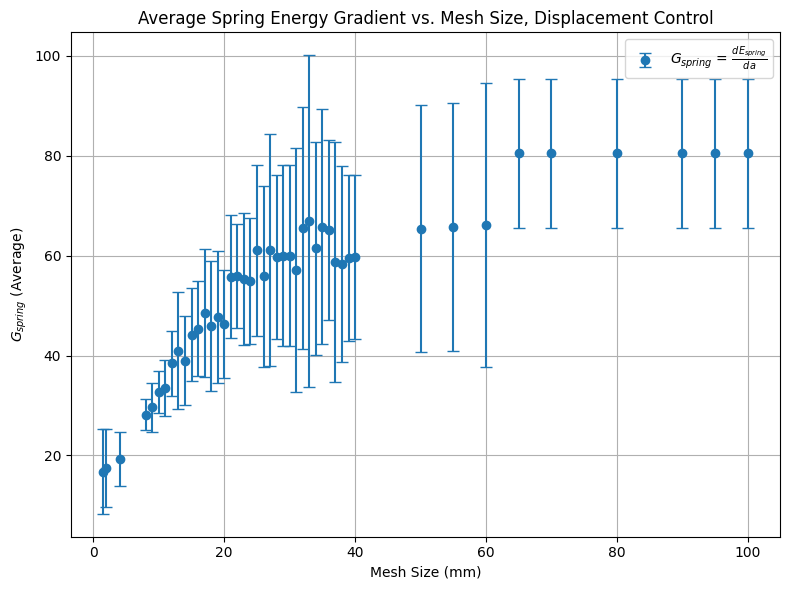

In [5]:
slope, intercept, r_value, p_value, std_err = linregress(MESH_SIZES, G_AVERAGE)
slope, intercept = DataProcessor.get_linear_regression(MESH_SIZES, G_AVERAGE, np.ones_like(MESH_SIZES), G_STD, slope, intercept)

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(MESH_SIZES, G_AVERAGE, yerr=G_STD, fmt='o', capsize=4, label=r'$G_{spring}$ = $\frac{dE_{spring}}{da}$')

x_fit = np.linspace(min(MESH_SIZES), max(MESH_SIZES), 100)
y_fit = slope * x_fit + intercept
# ax.plot(x_fit, y_fit, '-.', label='Linear fit')

r_squared = r_value**2
textstr = f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$'
# ax.text(0.05, 0.95, textstr, transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
# ax.set_xscale("log")
ax.set_xlabel('Mesh Size (mm)')
ax.set_ylabel(r'$G_{spring}$ (Average)')
ax.legend()
ax.grid(True)
plt.title('Average Spring Energy Gradient vs. Mesh Size, Displacement Control')
plt.tight_layout()
plt.savefig('./MeshDC/Plots/DC-Mesh-G.pdf', dpi=300)
plt.show()
plt.close()

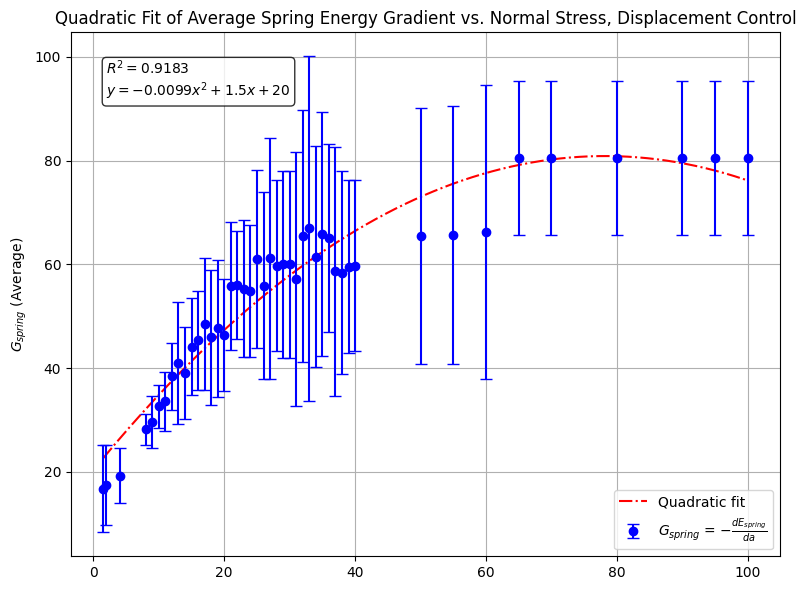

In [6]:
X = np.column_stack((MESH_SIZES**2, MESH_SIZES))
X = sm.add_constant(X)

model = sm.OLS(G_AVERAGE, X)
results = model.fit()
a, b, c = results.params[1], results.params[2], results.params[0]
r_squared = results.rsquared

x_fit = np.linspace(min(MESH_SIZES), max(MESH_SIZES), 200)
y_fit = a * x_fit**2 + b * x_fit + c

plt.figure(figsize=(8, 6))
plt.plot(x_fit, y_fit, 'r-.', label='Quadratic fit')
plt.errorbar(MESH_SIZES, G_AVERAGE, yerr=G_STD, color='blue', fmt='o', capsize=4, label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')
plt.text(0.05, 0.95, f'$R^2 = {r_squared:.4f}$\n$y = {a:.2g}x^2 + {b:.2g}x + {c:.2g}$', transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Mesh Size (mm)')
plt.ylabel(r'$G_{spring}$ (Average)')
plt.title('Quadratic Fit of Average Spring Energy Gradient vs. Normal Stress, Displacement Control')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('./MeshDC/Plots/DC-Mesh-G-Quadratic.pdf', dpi=300)
plt.show()

Exponential Saturation:
  R² = 0.9479
  AIC = 126.69
  Parameters: [7.28537194e+01 3.91030731e-02 9.46729724e+00]

Hyperbolic:
  R² = 0.9480
  AIC = 126.64
  Parameters: [97.85363399 27.91364399  7.60867456]

Logarithmic:
  R² = 0.9322
  AIC = 138.59
  Parameters: [28.59944224  0.16334351  5.96318391]

Power Law:
  R² = 0.9149
  AIC = 148.79
  Parameters: [ 27.81619153   0.29868809 -21.28207964]

Best model (by R²): Hyperbolic


/var/folders/3_/nmxnf4m14bq6l5lt8nd299xh0000gp/T/ipykernel_66460/3845626853.py:17: RuntimeWarning: invalid value encountered in log
  return a * np.log(b * x + 1) + c


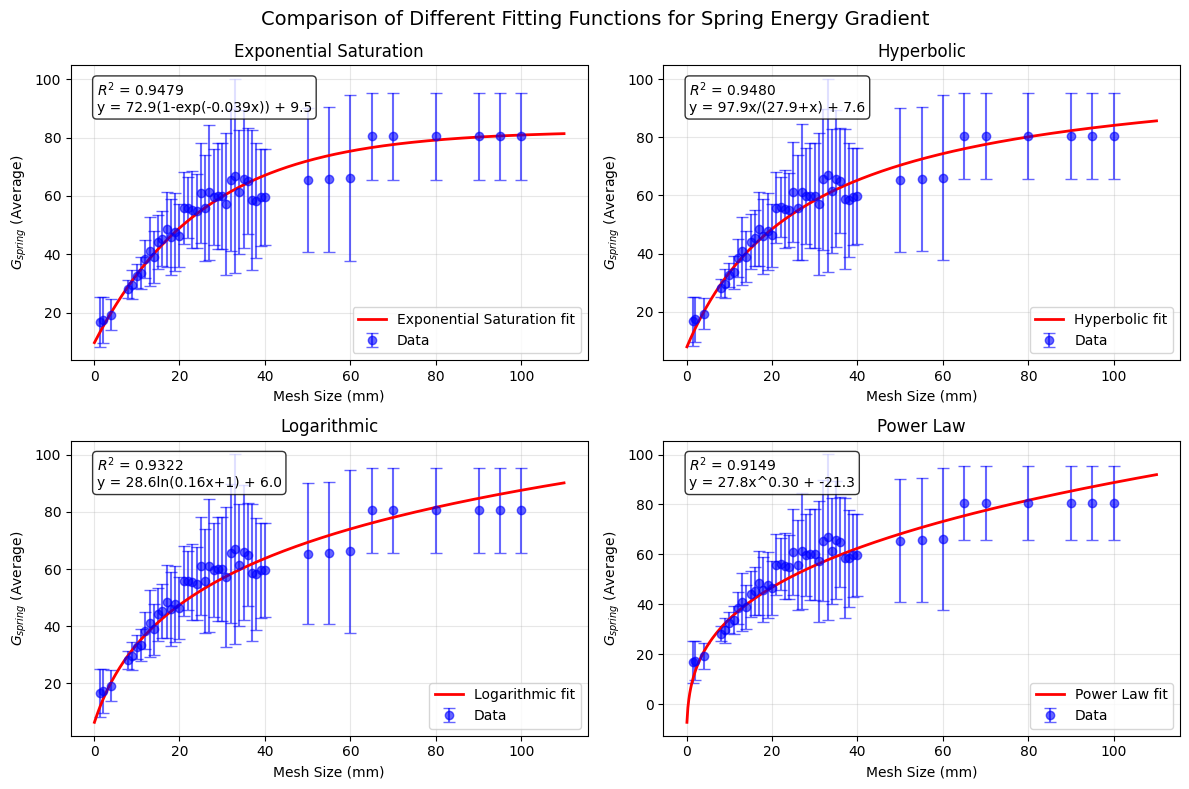

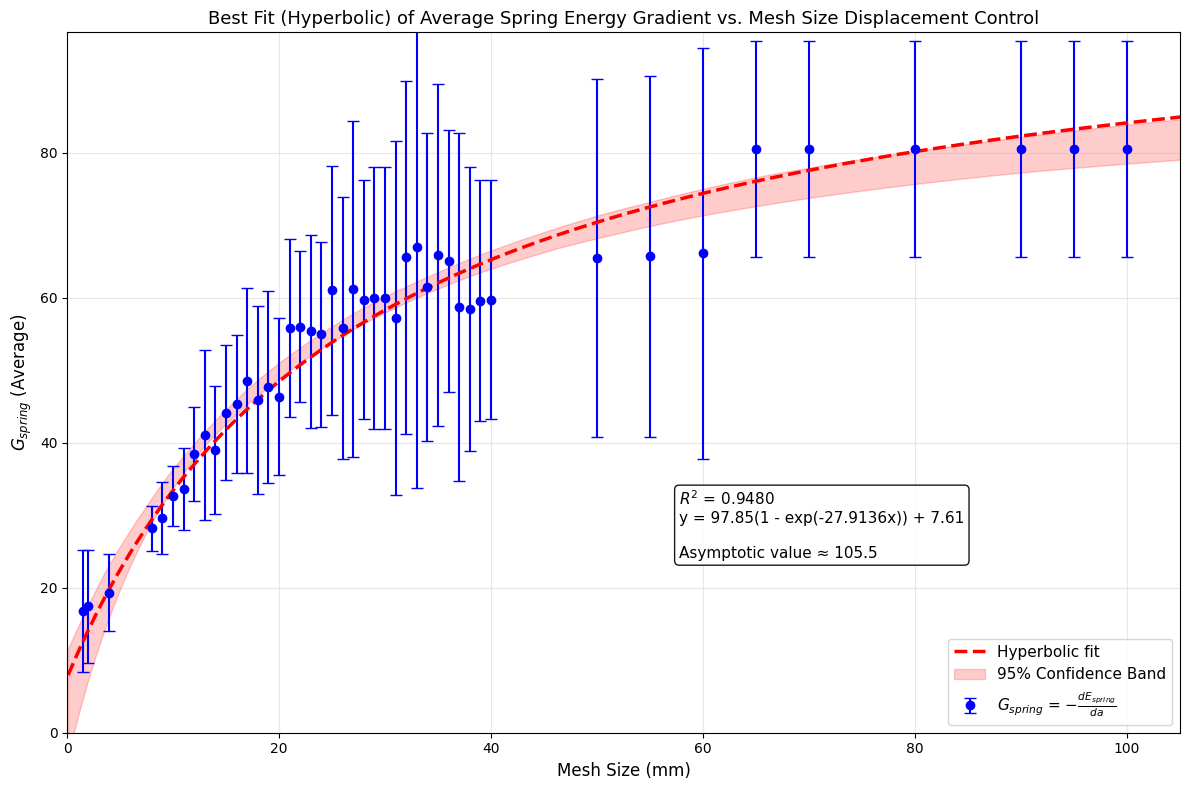


Best Model: Hyperbolic
Parameters: [97.85363399 27.91364399  7.60867456]
R² Score: 0.947992
AIC: 126.64


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# 定義不同的擬合函數
def exponential_saturation(x, a, b, c):
    """指數飽和函數: y = a * (1 - exp(-b*x)) + c"""
    return a * (1 - np.exp(-b * x)) + c

def hyperbolic(x, a, b, c):
    """雙曲線函數: y = a*x / (b + x) + c"""
    return a * x / (b + x) + c

def logarithmic(x, a, b, c):
    """對數函數: y = a * log(b*x + 1) + c"""
    return a * np.log(b * x + 1) + c

def power_law(x, a, b, c):
    """冪律函數: y = a * x^b + c"""
    return a * np.power(x, b) + c

# 準備數據 (假設你已經有了 MESH_SIZES, G_AVERAGE, G_STD)
# MESH_SIZES = np.array([...])
# G_AVERAGE = np.array([...])
# G_STD = np.array([...])

# 設定初始猜測值
initial_guess = [80, 0.1, 0]  # 對於指數飽和函數

# 擬合不同的函數
models = {
    'Exponential Saturation': (exponential_saturation, [80, 0.1, 0]),
    'Hyperbolic': (hyperbolic, [100, 10, 0]),
    'Logarithmic': (logarithmic, [20, 0.5, 10]),
    'Power Law': (power_law, [20, 0.5, 0])
}

# 儲存擬合結果
fit_results = {}

for name, (func, init_params) in models.items():
    try:
        # 使用誤差權重進行擬合
        popt, pcov = curve_fit(func, MESH_SIZES, G_AVERAGE, 
                              p0=init_params, 
                              sigma=G_STD, 
                              absolute_sigma=True,
                              maxfev=5000)
        
        # 計算R²
        y_pred = func(MESH_SIZES, *popt)
        r2 = r2_score(G_AVERAGE, y_pred)
        
        # 計算AIC (Akaike Information Criterion) 用於模型比較
        residuals = G_AVERAGE - y_pred
        sse = np.sum(residuals**2)
        n = len(MESH_SIZES)
        k = len(popt)
        aic = n * np.log(sse/n) + 2*k
        
        fit_results[name] = {
            'params': popt,
            'r2': r2,
            'aic': aic,
            'func': func
        }
        
        print(f"{name}:")
        print(f"  R² = {r2:.4f}")
        print(f"  AIC = {aic:.2f}")
        print(f"  Parameters: {popt}")
        print()
        
    except Exception as e:
        print(f"Failed to fit {name}: {e}")

# 找出最佳模型 (基於R²)
best_model = max(fit_results.keys(), key=lambda x: fit_results[x]['r2'])
print(f"Best model (by R²): {best_model}")

# 繪製比較圖
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

x_fit = np.linspace(0.1, max(MESH_SIZES)*1.1, 500)

for idx, (name, results) in enumerate(fit_results.items()):
    ax = axes[idx]
    
    # 繪製數據點
    ax.errorbar(MESH_SIZES, G_AVERAGE, yerr=G_STD, 
                color='blue', fmt='o', capsize=4, alpha=0.6,
                label='Data')
    
    # 繪製擬合曲線
    y_fit = results['func'](x_fit, *results['params'])
    ax.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'{name} fit')
    
    # 添加統計信息
    params = results['params']
    r2 = results['r2']
    
    # 根據不同函數類型顯示方程式
    if name == 'Exponential Saturation':
        eq_text = f'y = {params[0]:.1f}(1-exp(-{params[1]:.3f}x)) + {params[2]:.1f}'
    elif name == 'Hyperbolic':
        eq_text = f'y = {params[0]:.1f}x/({params[1]:.1f}+x) + {params[2]:.1f}'
    elif name == 'Logarithmic':
        eq_text = f'y = {params[0]:.1f}ln({params[1]:.2f}x+1) + {params[2]:.1f}'
    elif name == 'Power Law':
        eq_text = f'y = {params[0]:.1f}x^{params[1]:.2f} + {params[2]:.1f}'
    
    ax.text(0.05, 0.95, f'$R^2$ = {r2:.4f}\n{eq_text}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Mesh Size (mm)')
    ax.set_ylabel(r'$G_{spring}$ (Average)')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right')

plt.suptitle('Comparison of Different Fitting Functions for Spring Energy Gradient', fontsize=14)
plt.tight_layout()
plt.savefig('./MeshDC/Plots/DC-Mesh-G-Comparison.pdf', dpi=300)
plt.show()

# 繪製最佳擬合模型的單獨圖
plt.figure(figsize=(12, 8))
best_results = fit_results[best_model]

# 數據點
plt.errorbar(MESH_SIZES, G_AVERAGE, yerr=G_STD, 
            color='blue', fmt='o', capsize=4, markersize=6,
            label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')

# 擬合曲線
y_fit_best = best_results['func'](x_fit, *best_results['params'])
plt.plot(x_fit, y_fit_best, 'r--', linewidth=2.5, label=f'{best_model} fit')

# 添加95%置信區間 (如果需要)
# 這裡使用bootstrap方法估計
n_bootstrap = 100
y_bootstrap = []
for _ in range(n_bootstrap):
    # 重新採樣
    indices = np.random.choice(len(MESH_SIZES), len(MESH_SIZES), replace=True)
    x_sample = MESH_SIZES[indices]
    y_sample = G_AVERAGE[indices]
    
    try:
        popt_sample, _ = curve_fit(best_results['func'], x_sample, y_sample, 
                                   p0=best_results['params'], maxfev=5000)
        y_bootstrap.append(best_results['func'](x_fit, *popt_sample))
    except:
        pass

if y_bootstrap:
    y_bootstrap = np.array(y_bootstrap)
    y_lower = np.percentile(y_bootstrap, 2.5, axis=0)
    y_upper = np.percentile(y_bootstrap, 97.5, axis=0)
    plt.fill_between(x_fit, y_lower, y_upper, alpha=0.2, color='red', 
                     label='95% Confidence Band')

# 添加文字說明
params = best_results['params']
r2 = best_results['r2']

if best_model == 'Exponential Saturation' or True:
    eq_text = f'y = {params[0]:.2f}(1 - exp(-{params[1]:.4f}x)) + {params[2]:.2f}'
    plt.text(0.55, 0.25, f'$R^2$ = {r2:.4f}\n{eq_text}\n\nAsymptotic value ≈ {params[0]+params[2]:.1f}',
             transform=plt.gca().transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.xlabel('Mesh Size (mm)', fontsize=12)
plt.ylabel(r'$G_{spring}$ (Average)', fontsize=12)
plt.title(f'Best Fit ({best_model}) of Average Spring Energy Gradient vs. Mesh Size Displacement Control', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, max(MESH_SIZES)*1.05)
plt.ylim(0, max(G_AVERAGE)*1.2)

plt.tight_layout()
plt.savefig('./MeshDC/Plots/DC-Mesh-G-BestFit.pdf', dpi=300)
plt.show()

# 輸出詳細的擬合參數
print("\n" + "="*50)
print(f"Best Model: {best_model}")
print("="*50)
print(f"Parameters: {best_results['params']}")
print(f"R² Score: {best_results['r2']:.6f}")
print(f"AIC: {best_results['aic']:.2f}")

if best_model == 'Exponential Saturation':
    a, b, c = best_results['params']
    print(f"\nPhysical Interpretation:")
    print(f"  - Asymptotic value: {a + c:.2f}")
    print(f"  - Characteristic mesh size (1/b): {1/b:.2f} mm")
    print(f"  - Initial value (at x=0): {c:.2f}")